# R17 - Predictions with Deep Learning Regression (CNN / RNN / LSTM)

In [166]:
# Import libraries and set a random state
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import lime, shap
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, GridSearchCV

import tensorflow as tf
from keras.utils import pad_sequences
from keras.layers import Input, Dense, LSTM, GRU, SimpleRNN, Embedding
from keras.layers import Dropout, Activation, Bidirectional, GlobalMaxPool1D
from keras.layers.convolutional import Conv1D, Conv2D
from keras.layers.convolutional import MaxPooling1D, MaxPooling2D
from keras.models import Sequential
from keras import initializers, regularizers, constraints, optimizers, layers
from keras.preprocessing import text, sequence
from keras.layers import Flatten
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras import regularizers
from keras.wrappers.scikit_learn import KerasClassifier #to use Keras in sklearn

import warnings
warnings.filterwarnings('ignore')
# random_state = random.randint(1,30)
random_state = 2;  dl_model = 3;  dropna_type = 1;  subset_type = 1;  column_type = 15;  cv_fold = 10

In [167]:
# Read the salary dataset, drop 'id' duplicates
salaries = pd.read_csv('Salaries_v4_202412161100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_3).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded_2).csv')
# salaries = pd.read_csv('Salaries_v3_202410141100(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408271150(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202408021730(expanded).csv')
# salaries = pd.read_csv('Salaries_v3_202402121435.csv')
# salaries = pd.read_csv('Salaries_v3_202401081515.csv')
salaries = salaries.drop_duplicates('id').reset_index()
salaries = salaries.drop(['index','Unnamed: 0'],axis=1)
print("### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###")
print(salaries.isnull().sum()[:16])

### COUNTS OF MISSING VALUES FOR DEFAULT COLUMNS ###
id                      0
found_country           0
title                  12
position                0
employment_type      7157
company              2618
company_score        3815
edu_degrees           554
edu_degrees_major     931
working_year            0
education_score      4598
ms_counts               0
skill_counts            0
main_skills             0
skills                  0
amount_usd              0
dtype: int64


## Select Dropping of Missing Values Strategy

In [168]:
if dropna_type == 1:    print("ROWS WITH MISSING VALUES ARE NOT DROPPED");  
elif dropna_type == 2:  print("DROPPED ALL ROWS WITH MISSING VALUES");  salaries.dropna(inplace=True)
elif dropna_type == 3:  print("DROPPED ROWS WITH MISSING found_country");  salaries.dropna(subset=['found_country'], inplace=True)
elif dropna_type == 4:  print("DROPPED ROWS WITH MISSING title");  salaries.dropna(subset=['title'], inplace=True)
elif dropna_type == 5:  
    print("DROPPED ROWS WITH MISSING employment_type");  salaries.dropna(axis=0, subset=['employment_type'], inplace=True)
elif dropna_type == 6:  print("DROPPED ROWS WITH MISSING company");  salaries.dropna(axis=0, subset=['company'], inplace=True)
elif dropna_type == 7:  
    print("DROPPED ROWS WITH MISSING company_score");  salaries.dropna(axis=0, subset=['company_score'], inplace=True)
elif dropna_type == 8:  print("DROPPED ROWS WITH MISSING edu_degrees");  salaries.dropna(axis=0, subset=['edu_degrees'], inplace=True)
elif dropna_type == 9:  
    print("DROPPED ROWS WITH MISSING edu_degrees_major");  salaries.dropna(axis=0, subset=['edu_degrees_major'], inplace=True)
elif dropna_type == 10:  
    print("DROPPED ROWS WITH MISSING education_score");  salaries.dropna(axis=0, subset=['education_score'], inplace=True)
else:  raise ValueError('Drop N/A type must be between 1 and 10!')

print("This salary dataset contains {} ROWS & {} COLUMNS (DROP N/A TYPE: {})".format(
    salaries.shape[0], salaries.shape[1], dropna_type))

ROWS WITH MISSING VALUES ARE NOT DROPPED
This salary dataset contains 19554 ROWS & 135 COLUMNS (DROP N/A TYPE: 1)


## Dataset Information

In [169]:
# Get the first few rows of the dataset
salaries.head()

,id,found_country,title,position,employment_type,company,company_score,edu_degrees,edu_degrees_major,working_year,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
0,0000083c-7054-4a2b-b675-6ac664c66bfb,United States,"Software Developer II at Audible, Inc.",Software Developer II,Full-time,"Audible, Inc.",8.9,"HIGH_SCHOOL,MASTERS,UNDERGRADUATE","Bachelor’s Degree, Computer Science,High Schoo...",11,...,0,0,1,0,0,0,0,0,1,0
1,00013847-ecf1-4a5a-ba44-16475dc28eba,United States,Retail Associate at Converse,Retail Associate,Full-time,NaN,NaN,UNDERGRADUATE,NaN,5,...,0,0,0,0,1,0,0,0,0,1
2,00018332-5b5d-4c23-88f8-1c2cdc133e28,United Kingdom,Test Engineer at Sky,Test Engineer,Full-time,NaN,NaN,UNDERGRADUATE,"Bachelor of Science (BSc), Computer Software E...",12,...,0,0,0,0,0,0,0,0,0,1
3,000c1054-ab28-4c4d-90b0-fa4b1ed31a2a,United States,Hardware Engineer at Google,Hardware Engineer,NaN,Google,8.7,MASTERS,"Master of Science (MS), Computer Engineering",13,...,0,0,0,0,0,0,0,0,0,0
4,00145b03-e286-4bdc-9063-ed5d2095306a,United States,BI Engineer @ Amazon | MS,BIE II,NaN,Amazon,8.4,MASTERS,"Master of Science - MS, Data Analytics",3,...,0,0,0,1,0,0,1,0,0,0


In [170]:
# Get necessary info about the dataset
salaries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19554 entries, 0 to 19553
Columns: 135 entries, id to skill_communication
dtypes: float64(27), int64(98), object(10)
memory usage: 20.1+ MB


In [171]:
# Get stats about the numerical columns
salaries.describe()

,company_score,working_year,education_score,ms_counts,skill_counts,amount_usd,country_coef,country_usa,country_uk,title_slr_coef,...,skill_leadership,skill_data_anly,skill_cpp,skill_javascript,skill_cust_serv,skill_mac_learn,skill_research,skill_proj_man,skill_html,skill_communication
count,15739.000000,19554.000000,14956.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,...,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000,19554.000000
mean,8.248993,11.449882,8.401484,15.738008,18.777948,163366.552981,0.966054,0.912959,0.087041,0.452360,...,0.258055,0.211824,0.197095,0.177202,0.179094,0.153370,0.205840,0.168252,0.169275,0.193157
std,0.561583,7.213469,1.383108,7.306042,7.814769,81118.159433,0.109942,0.281902,0.281902,0.145708,...,0.437575,0.408611,0.397815,0.381849,0.383441,0.360353,0.404325,0.374099,0.375004,0.394786
min,3.800000,0.000000,1.600000,1.000000,1.000000,21000.000000,0.610000,0.000000,0.000000,0.102000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.100000,6.000000,7.500000,11.000000,15.000000,102000.000000,1.000000,1.000000,0.000000,0.350000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.400000,10.000000,8.600000,16.000000,20.000000,150000.000000,1.000000,1.000000,0.000000,0.484000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.600000,15.000000,9.700000,20.000000,20.000000,210000.000000,1.000000,1.000000,0.000000,0.539000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,57.000000,10.000000,56.000000,82.000000,560000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Select Rows / Columns & Make Train-Test Splits

In [172]:
## GET ANY SUBSET OF THE DATASET
if subset_type == 1:  print("FULL DATASET IS BEING USED")
## Countries
elif subset_type == 2:  print("SUBSET: country_usa");  salaries = salaries[salaries['country_usa'] == 1]
elif subset_type == 3:  print("SUBSET: country_uk");  salaries = salaries[salaries['country_uk'] == 1]
## Titles
elif subset_type == 4:  print("SUBSET: title_has_seniority");  salaries = salaries[salaries['title_has_seniority'] == 1]
elif subset_type == 5:  print("SUBSET: tt_software_eng");  salaries = salaries[salaries['tt_software_eng'] == 1]
elif subset_type == 6:  print("SUBSET: tt_data_analyst");  salaries = salaries[salaries['tt_data_analyst'] == 1]
elif subset_type == 7:  print("SUBSET: tt_data_scientist");  salaries = salaries[salaries['tt_data_scientist'] == 1]
elif subset_type == 8:  print("SUBSET: tt_machine_learning");  salaries = salaries[salaries['tt_machine_learning'] == 1]
elif subset_type == 9:  print("SUBSET: tt_program_manager");  salaries = salaries[salaries['tt_program_manager'] == 1]
## Positions
elif subset_type == 10:  print("SUBSET: position_has_seniority");  salaries = salaries[salaries['position_has_seniority'] == 1]
elif subset_type == 11:  print("SUBSET: pos_software_eng");  salaries = salaries[salaries['pos_software_eng'] == 1]
elif subset_type == 12:  print("SUBSET: pos_data_analyst");  salaries = salaries[salaries['pos_data_analyst'] == 1]
elif subset_type == 13:  print("SUBSET: pos_machine_learning");  salaries = salaries[salaries['pos_machine_learning'] == 1]
elif subset_type == 14:  print("SUBSET: pos_program_manager");  salaries = salaries[salaries['pos_program_manager'] == 1]
elif subset_type == 15:  print("SUBSET: pos_network_engineer");  salaries = salaries[salaries['pos_network_engineer'] == 1]
## Educations
elif subset_type == 16:  print("SUBSET: phd_degree");  salaries = salaries[salaries['phd_degree'] == 1]
elif subset_type == 17:  print("SUBSET: master_degree");  salaries = salaries[salaries['master_degree'] == 1]
elif subset_type == 18:  print("SUBSET: undergrad_degree");  salaries = salaries[salaries['undergrad_degree'] == 1]
## Companies
elif subset_type == 19:  print("SUBSET: comp_google");  salaries = salaries[salaries['comp_google'] == 1]
elif subset_type == 20:  print("SUBSET: comp_amazon");  salaries = salaries[salaries['comp_amazon'] == 1]
elif subset_type == 21:  print("SUBSET: comp_oracle");  salaries = salaries[salaries['comp_oracle'] == 1]
elif subset_type == 22:  print("SUBSET: comp_microsoft");  salaries = salaries[salaries['comp_microsoft'] == 1]
elif subset_type == 23:  print("SUBSET: comp_apple");  salaries = salaries[salaries['comp_apple'] == 1]
elif subset_type == 24:  print("SUBSET: comp_linkedin");  salaries = salaries[salaries['comp_linkedin'] == 1]
## Main Skills
elif subset_type == 25:  print("SUBSET: ms_python");  salaries = salaries[salaries['ms_python'] == 1]
elif subset_type == 26:  print("SUBSET: ms_data_eng");  salaries = salaries[salaries['ms_data_eng'] == 1]
elif subset_type == 27:  print("SUBSET: ms_java");  salaries = salaries[salaries['ms_java'] == 1]
elif subset_type == 28:  print("SUBSET: ms_cpp");  salaries = salaries[salaries['ms_cpp'] == 1]
elif subset_type == 29:  print("SUBSET: ms_mac_learn");  salaries = salaries[salaries['ms_mac_learn'] == 1]
elif subset_type == 30:  print("SUBSET: ms_software_dev");  salaries = salaries[salaries['ms_software_dev'] == 1]
else:  raise ValueError('Salaries subset type must be between 1 and 30!')

# Fill the null values with average for some columns
salaries['company_score'] = salaries['company_score'].fillna(salaries['company_score'].mean())
salaries['education_score'] = salaries['education_score'].fillna(salaries['education_score'].mean())

## GET ANY SUBCOLUMNS OF THE DATASET
if column_type == 1:
    print("BASE NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','amount_usd']]
elif column_type == 2:
    print("ALL NUMERICAL COLUMNS")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef','country_usa', \
                         'country_uk','title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist', \
                         'tt_machine_learning','tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng', \
                         'tt_bi_analyst','tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer', \
                         'position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng',
                         'employment_full_time','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','comp_amazon','comp_google','comp_oracle','comp_microsoft', \
                         'comp_meta','comp_apple','comp_cisco','comp_aws','comp_ibm','comp_linkedin','comp_capitalone', \
                         'comp_jpmorgan','comp_intel','comp_saic','comp_tata','comp_intuit','comp_uber','comp_qualcomm', \
                         'comp_salesforce','comp_stripe','ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming', \
                         'ms_java','ms_office','ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res', \
                         'ms_html','ms_mac_learn','ms_proj_man','ms_software_dev','ms_cust_serv','ms_research', \
                         'skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 3:
    print("NUMERICAL COLUMNS ONLY WITH >=0.1 CORRELATION")
    salaries = salaries[['company_score','working_year','education_score','country_coef','country_usa','title_has_seniority', \
                         'tt_data_scientist','tt_machine_learning','tt_program_manager','tt_product_manager', \
                         'position_has_seniority','pos_data_scientist','pos_machine_learning','pos_program_manager', \
                         'pos_product_manager','highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree', \
                         'ed_computer_eng','ed_computer_science','ed_electric_electronic','ed_philosophy', \
                         'comp_google','comp_apple','comp_linkedin','comp_stripe','ms_python','ms_data_eng','ms_sql', \
                         'ms_cpp','ms_mac_learn','ms_software_dev','skill_sql','skill_python','skill_cpp','skill_mac_learn', \
                         'amount_usd']]
elif column_type == 4:
    print("TITLE COLUMNS ONLY")
    salaries = salaries[['title_has_seniority','tt_software_eng','tt_data_analyst','tt_data_scientist','tt_machine_learning', \
                         'tt_program_manager','tt_bi_engineer','tt_ux_ui_designer','tt_app_dev_eng','tt_bi_analyst', \
                         'tt_devops_eng','tt_network_eng','tt_product_manager','tt_qa_engineer','amount_usd']]
elif column_type == 5:
    print("POSITION COLUMNS ONLY")
    salaries = salaries[['position_has_seniority','pos_software_eng','pos_data_analyst','pos_data_scientist', \
                         'pos_machine_learning','pos_program_manager','pos_network_engineer','pos_product_manager', \
                         'pos_project_manager','pos_ux_ui_designer','pos_business_analyst','pos_devops_eng','amount_usd']]
elif column_type == 6:
    print("EDUCATION DEGREE COLUMNS ONLY")
    salaries = salaries[['highest_edu_deg_lvl','phd_degree','master_degree','undergrad_degree','amount_usd']]
elif column_type == 7:
    print("EDUCATION DEGREE MAJOR COLUMNS ONLY")
    salaries = salaries[['ed_arts','ed_business_admin','ed_computer_eng','ed_computer_science','ed_electric_electronic', \
                         'ed_info_tech','ed_math','ed_philosophy','amount_usd']]
elif column_type == 8:
    print("COMPANY COLUMNS ONLY")
    salaries = salaries[['comp_amazon','comp_google','comp_oracle','comp_microsoft','comp_meta','comp_apple','comp_cisco', \
                         'comp_aws','comp_ibm','comp_linkedin','comp_capitalone','comp_jpmorgan','comp_intel','comp_saic', \
                         'comp_tata','comp_intuit','comp_uber','comp_qualcomm','comp_salesforce','comp_stripe','amount_usd']]
elif column_type == 9:
    print("MAIN SKILL COLUMNS ONLY")
    salaries = salaries[['ms_fin_man','ms_python','ms_data_eng','ms_sql','ms_programming','ms_java','ms_office', \
                         'ms_data_anly','ms_leadership','ms_cpp','ms_javascript','ms_market_res','ms_html','ms_mac_learn', \
                         'ms_proj_man','ms_software_dev','ms_cust_serv','ms_research','amount_usd']]
elif column_type == 10:
    print("SKILL COLUMNS ONLY")
    salaries = salaries[['skill_office','skill_sql','skill_java','skill_python','skill_leadership','skill_data_anly', \
                         'skill_cpp','skill_javascript','skill_cust_serv','skill_mac_learn','skill_research','skill_proj_man', \
                         'skill_html','skill_communication','amount_usd']]
elif column_type == 11:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 10)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst','amount_usd']]
elif column_type == 12:
    print("MOST POSITIVELY AND NEGATIVELY CORRELATED COLUMNS ONLY (BOTH TOP 20)")
    salaries = salaries[['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts','amount_usd']]
elif column_type == 13:
    print("TOP 25 POSITIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries [['company_score','position_has_seniority','comp_google','country_usa','country_coef', \
                         'title_has_seniority','comp_linkedin','highest_edu_deg_lvl','master_degree','phd_degree', \
                         'education_score','skill_mac_learn','ms_mac_learn','skill_cpp','ms_cpp', \
                         'working_year','skill_python','ed_philosophy','ms_python','pos_data_scientist', \
                         'ed_computer_science','pos_machine_learning','tt_product_manager','tt_machine_learning','pos_product_manager', \
                         'amount_usd']]
elif column_type == 14:
    print("TOP 25 NEGATIVELY CORRELATED COLUMNS (BASED ON DATETIME 2024-10-14)")
    salaries = salaries[['country_uk','ms_cust_serv','skill_cust_serv','skill_communication','ms_office', \
                         'skill_office','skill_leadership','ms_leadership','ms_fin_man','pos_data_analyst', \
                         'tt_data_analyst','tt_bi_analyst','comp_tata','pos_business_analyst','comp_jpmorgan', \
                         'employment_full_time','ed_arts','comp_ibm','ed_business_admin','skill_counts', \
                         'ms_counts','ms_market_res','comp_saic','tt_qa_engineer','ms_research','amount_usd']]
elif column_type == 15:
    print("BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER")
    salaries = salaries[['company_score','working_year','education_score','ms_counts','skill_counts','country_coef', \
                         'title_slr_coef','title_seniority_slr_coef','position_slr_coef','position_seniority_slr_coef', \
                         'employment_type_coef','employment_type_slr_coef','highest_edu_deg_lvl','edu_deg_slr_coef', \
                         'edu_degree_major_coef_max','company_slr_coef','main_skill_slr_coef_avg','amount_usd']]
else:
    raise ValueError('Salaries column type must be between 1 and 10!')

print("SUBSET TYPE:", subset_type, "  COLUMN TYPE:", column_type, "  DATASET SHAPE:", salaries.shape)

FULL DATASET IS BEING USED
BASE NUMERICAL AND NORMALIZED COLUMNS TOGETHER
SUBSET TYPE: 1   COLUMN TYPE: 15   DATASET SHAPE: (19554, 18)


In [173]:
# OPTION 1: Make train and test splits; 90% train and 10% test
random_state_in_use = True
X = salaries.drop('amount_usd',axis=1)
y = salaries['amount_usd']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state)
print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

TRAIN SIZE: (17598, 17) (17598,)  TEST SIZE: (1956, 17) (1956,)


In [174]:
# OPTION 2: Separate train and test sets with exact boundary
# random_state_in_use = False
# X = salaries_alt.drop('amount_usd',axis=1)
# y = salaries_alt['amount_usd']
# x_train = X[:9000];   y_train = y[:9000]
# x_test = X[9000:];    y_test = y[9000:]
# print("TRAIN SIZE:", x_train.shape, y_train.shape, " TEST SIZE:", x_test.shape, y_test.shape)

## Create the DL Model & Evaluate the Predictions

In [175]:
# DEEP LEARNING MODEL (CNN & LSTM)
# A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one
# output tensor.

# Embedding: Turns positive integers (indexes) into dense vectors of fixed size.
#   e.g. [[4], [20]] -> [[0.25, 0.1], [0.6, -0.2]]
# This layer can only be used on positive integer inputs of a fixed range.
#   input_dim -> Integer. Size of the vocabulary, i.e., maximum integer index + 1
#   output_dim -> Integer. Dimension of the dense embedding

# Conv1D: 1D convolutional layer (e.g. temporal convolution). 
# This layer creates a convolutional kernel that is convolved with the layer input over a single spatial (or temporal) 
# dimension to produce a tensor of outputs.
# If 'use_bias' is True, a bias vector is created and added to the outputs. Finally, if 'activation' is not 'None', 
# it is applied to the outputs as well.
#   filters -> int, the dimension of the output space (the number of filters in the convolution)
#   kernel_size -> int or tuple/list of 1 integer, specifying the size of th convolution window
#   padding -> string, "valid", "same" or "causal" (case-insensitive)
#     "valid" means no padding
#     "same" results in padding evenly to the left/right or up/down of the input
#     When padding="same" and strides=1, the output has the same size as the input
#     "causal" results in causal (dilated) convolutions, e.g. output[t] does not depend on input[t+1:]
#     Useful when modeling temporal data where the model should not violate the temporal order
#     activation -> Activation function. If 'None', no activation is applied.

# Dense: Just your regular densely-connected NN layer. Dense implements the operation:
# output = activation(dot(input, kernel) + bias) where 'activation' is the element-wise activation function passed as the
# 'activation' argument, 'kernel' is a weights matrix created by the layer, and 'bias' is a bias vector created by the layer
# (only applicable if 'use_bias' is True).
#   units -> Positive integer, dimensionality of the output space
#   activation -> Activation function to use. If you don't specify anything, no activation is applied
#     (i.e. "linear" activation: a(x) = x)

# MaxPooling1D: Max pooling operation for 1D temporal data. 
# Downsamples the input representation by taking the maximum value over a spatial window of size 'pool_size'.
# The window is shifted by 'strides'.
# The resulting output when using the 'valid' padding option has a shape of:
#   output_shape = (input_shape - pool_size + 1) / strides
# The resulting output shape when using the "same" padding option is: output_shape = input_shape / strides
#   pool_size -> int, size of the max pooling window
#   strides -> int or None. Specifies how much the pooling window moves for each pooling step.
#   If None, it will default to 'pool_size'.

# GlobalMaxPooling1D: Global max pooling operation for temporal data.

# Dropout: Applies dropout to the input. 
# The Dropout layer randomly sets input units to 0 with a frequency of 'rate' at each step during training time, 
# which helps prevent overfitting. Inputs not set to 0 are scaled up by 1 / (1 - rate) such that the sum over all inputs 
# is unchanged.
# Note that the Dropout layer only applies when 'training' is set to True in 'call()', such that no values are dropped
# during inference. When using 'model.fit', 'training' will be appropriately set to True automatically.
# In other contexts, you can set the argument explicitly to True when calling the layer.
# (This is in contrast to setting 'trainable=False' for a Dropout layer. 'trainable' does not affect the layer's behavior,
# as Dropout does not have any variables/weights that can be frozen during training.)
#   rate -> Float between 0 and 1. Fraction of the inputs to drop

# LSTM: Long Short-Term Memory layer - Hochreiter 1997
# Based on available runtime hardware and constraints, this layer will choose different implementations (cuDNN-based or
# backend-native) to maximize the performance. If a GPU is available and all the arguments to the layer meet the
# requirement of the cuDNN kernel, the layer will use a fast cuDNN implementation when using the TensorFlow backend.
#   units -> Positive integer, dimensionality of the output space
#   activation -> Activation function to use.
#   Default: hyperbolic tangent (tanh). If you pass None, no activation is applied (i.e. "linear" activation: a(x) = x)
#   use_bias -> Boolean (default = True), whether the layer should use a bias vector.

# Flatten: Flattens the input. Does not affect the batch size. 
# If inputs are shaped (batch,) without a feature axis, then flattening adds an extra channel dimension and 
# output shape is (batch, 1).

In [176]:
# Choose the deep learning model
if dl_model == 1:
    model = Sequential()
    model.add(Embedding(input_dim=1024, output_dim=128, input_length=x_train.shape[1]))
    model.add(Conv1D(filters=128, kernel_size=3, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.15))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(64, activation='relu'))
    model.add(Flatten())
    model.add(Dense(1, activation='linear'))
elif dl_model == 2:
    model = Sequential()
    model.add(Embedding(input_dim=1024, output_dim=64))
    model.add(GRU(256, return_sequences=True))
    model.add(SimpleRNN(64))
    model.add(Dense(1, activation='linear'))
elif dl_model == 3:
    model = Sequential()
    model.add(Embedding(input_dim=1024, output_dim=64))
    model.add(LSTM(256))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='linear'))

In [177]:
# Model training APIs: 'compile' method
# Configures the model for training.
#   optimizer --> String (name of the optimizer) or optimizer instance.
#   loss --> Loss function. May be a string (name of loss function), or a 'keras.losses.loss' instance.
#     A loss function is any callable with the signature 'loss = fn(y_true, y_pred)', where 'y_true' are the ground truth
#     values, and 'y_pred' are the model's predictions. 'y_true' should have shape (batch_size, d0, .. dN) (except in the
#     case of sparse loss functions such as sparse categorical crossentropy which expects integer arrays of shape
#     '(batch_size, d0, .. dN)'). The loss function should return a float tensor.
#   metrics --> List of metrics to be evaluated by the model during training and testing.
#     Each of this can be a string (name of a built-in function), function or 'keras.metric.Metric' instance.
#     Typically you will use 'metrics=['accuracy']'.
#     A function is any callable with the signature 'result = fn(y_true, _pred)'.

In [178]:
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mean_squared_error'])

In [179]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, None, 64)          65536     
                                                                 
 lstm_1 (LSTM)               (None, 256)               328704    
                                                                 
 dense_20 (Dense)            (None, 64)                16448     
                                                                 
 dense_21 (Dense)            (None, 1)                 65        
                                                                 
Total params: 410,753
Trainable params: 410,753
Non-trainable params: 0
_________________________________________________________________


In [180]:
# Model training APIs: 'fit' method
# Trains the model for a fixed number of epochs (dataset iterations)
#   x --> Input data. It could be:
#     - A NumPy array (or array-like), or a list of arrays (in case the model has multiple inputs)
#     - A tensor, or a list of tensors (in case the model has multiple inputs)
#     - A dict mapping input names to the corresponding array/tensors, if the model has named inputs
#     - A 'tf.data.Dataset'. Should return a tuple of either (inputs, targets) or (inputs, targets, sample_weights)
#     - A 'keras.utils.PyDataset' returning (inputs, targets) or (inputs, targets, sample_weights)
#   y --> Target data. Like the input data x, it could be either NumPy array(s) or backend-native tensors.
#     If x is a dataset, generator, or 'keras.utils.PyDataset' instance, y should not be specified (since targets will be
#     obtained from x)
#   batch_size --> Integer or None. Number of samples per gradient update. If unspecified, batch_size will default to 32.
#     Do not specify the batch_size if your data is in the form of datasets, generators, or 'keras.utils.PyDataset' instances
#     (since they generate batches)
#   epochs --> Integer. Number of epochs to train the model.
#     An epoch is an iteration over the entire x and y data provided (unless the 'steps_per_epoch' flag is set to something
#     other than None). Note that in conjunction with 'initial_epoch', epochs is to be understood as "final epoch". The model
#     is not trained for a number of iterations given by epochs, but merely until the epoch of index 'epochs' is reached.
#   callbacks --> List of 'keras.callbacks.Callback' instances. List of callbacks apply during training.
#     Note that 'keras.callbacks.ProgbarLogger' and 'keras.callbacks.History' callbacks are created automatically and
#     need not be passed to 'model.fit()'
#   validation_data --> Data on which to evaluate the loss and any model metrics at the end of each epoch.
#     The model will not be trained on this data. Thus, note the fact that the validation loss of data provided using
#     validation_split or validation_data is not affected by regularization layers like noise and dropout.
#     validation_data will override validation_split. It could be:
#     - A tuple (x_val, y_val) of NumPy arrays or tensors
#     - A tuple (x_val, y_val, val_sample_weights) of NumPy arrays
#     - A 'tf.data.Dataset'
#     - A Python generator or 'keras.utils.PyDataset' returning (inputs, targets) or (inputs, targets, sample_weights)

# EarlyStopping: Stop training when a monitored metric has stopped improving.
# Assuming the goal of a training is to minimize the loss. With this, the metric to be monitored would be 'loss', and
# mode would be 'min'. A model.fit() training loop will check at the end of every epoch whether the loss is no longer
# decreasing, considering the 'min_delta' and 'patience' if applicable. Once it's found no longer decreasing,
# model.stop_training is marked True and the training terminates.
# The quantity to be monitored needs to be available in 'logs' dict. To make it so, pass the loss or metrics at
# model.compile():
#   monitor --> Quantity to be monitored. Defaults to "val_loss"
#   patience --> Number of epochs with no improvement after which training will be stopped. Defaults to 0.
#   verbose --> Verbosity mode, 0 or 1. Mode 0 is silent, and mode 1 displays messages when the callback takes an action.
#     Defaults to 0.
#   mode --> One of {"auto", "min", "max"}. In 'min' mode, training will stop when the quantity monitored has stopped
#     decreasing; in 'max' mode, it will stop training when the quantity monitored has stopped increasing; in 'auto' mode,
#     the direction is automatically inferred from the name of the monitored quantity. Defaults to "auto"

In [181]:
s_time = time.time()
es = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
history = model.fit(x_train, y_train, epochs=30, callbacks=[es], validation_data=[x_test, y_test])
print(">>> FITTING TIME: {:.5f} seconds.".format(time.time()-s_time))

Epoch 1/30
550/550 [==============================] - 20s 33ms/step - loss: 161726.6094 - mean_squared_error: 32775036928.0000 - val_loss: 157587.4062 - val_mean_squared_error: 31083581440.0000
Epoch 2/30
550/550 [==============================] - 19s 34ms/step - loss: 152213.6562 - mean_squared_error: 29804083200.0000 - val_loss: 143736.0469 - val_mean_squared_error: 26909837312.0000
Epoch 3/30
550/550 [==============================] - 19s 34ms/step - loss: 134535.9531 - mean_squared_error: 24749873152.0000 - val_loss: 122502.1328 - val_mean_squared_error: 21242617856.0000
Epoch 4/30
550/550 [==============================] - 19s 34ms/step - loss: 111364.2656 - mean_squared_error: 18887051264.0000 - val_loss: 98406.8516 - val_mean_squared_error: 15550049280.0000
Epoch 5/30
550/550 [==============================] - 19s 34ms/step - loss: 88903.2422 - mean_squared_error: 13695197184.0000 - val_loss: 78888.3125 - val_mean_squared_error: 11077431296.0000
Epoch 6/30
550/550 [=============

In [182]:
# Model training APIs: 'evaluate' method
# Returns the loss value & metrics values for the model in test mode.
# Computation is done in batches (see the batch_size argument)
#   x --> Input data. It could be:
#     - A NumPy array (or array-like), or a list of arrays (in case the model has multiple inputs)
#     - A tensor, or a list of tensors (in case the model has multiple inputs)
#     - A dict mapping input names to the corresponding array/tensors, if the model has named inputs
#     - A 'tf.data.Dataset'. Should return a tuple of etiher (inputs, targets) or (inputs, targets, sample_weights).
#     - A generator or 'keras.utils.PyDataset' returning (inputs, targets) or (inputs, targets, sample_weights)
#   y --> Target data. Like the input data x, it could be either NumPy array(s) or backend-native tensor(s).
#     If x is a 'tf.data.Dataset' or 'keras.utils.PyDataset' instance, y should not be specified (since targets will be
#     obtained from the interator/dataset)
#   batch_size --> Integer or None. Number of samples per batch of computation. In unspecified, batch_size will default
#     to 32. Do not specify the batch_size if your data is in the form of a dataset, generators, or 'keras.utils.PyDataset'
#     instances (since they generate batches).
#   verbose --> "auto", 0, 1, or 2. Verbosity mode. 0 = silent, 1 = progress bar, 2 = single line.
#     "auto" becomes 1 for most cases. Note that the progress bar is not particularly useful when logged to a file, so
#     verbose=2 is recommended when not running interactively (e.g. in a production environment). Defaults to "auto".

Train MSE: 6805409792.00 | Test MSE: 6415912448.00
Train Loss: 62936.359375 | Test Loss: 62106.253906
>>> EVALUATION TIME: 8.89767 seconds.


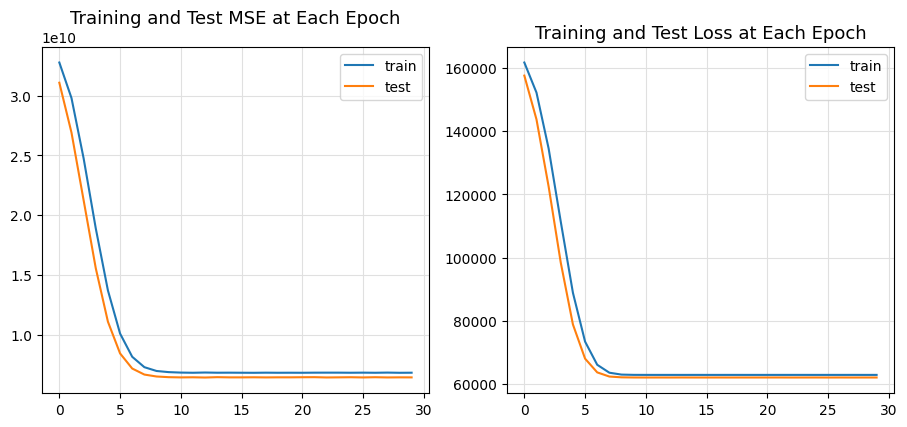

In [183]:
s_time = time.time()
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train MSE: %.2f | Test MSE: %.2f' % (train_mse, test_mse))
print('Train Loss: %.6f | Test Loss: %.6f' % (history.history['loss'][-1], history.history['val_loss'][-1]))
print(">>> EVALUATION TIME: {:.5f} seconds.".format(time.time()-s_time))
# Plot training history
plt.figure(figsize=(11,4.5))
plt.subplot(1,2,1)
plt.plot(history.history['mean_squared_error'], label='train')
plt.plot(history.history['val_mean_squared_error'], label='test')
plt.title('Training and Test MSE at Each Epoch', fontsize=13)
plt.grid(color='#e0e0e0')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Training and Test Loss at Each Epoch', fontsize=13)
plt.legend()
plt.grid(color='#e0e0e0')
plt.show()

In [184]:
# Model training APIs: 'predict' method
# Generates output predictions for the input samples.
# Computation is done in batches. This method is designed for batch processing of large numbers of inputs.
# It is not intended for use inside of loops that iterate over your data and process small number of inputs at a time.
# For small numbers of inputs that fit in one batch, directly use '__call__()' for faster execution, e.g. 'model(x)'
# or 'model(x, training=False)' if you have layers such as 'BatchNormalization' that behave differently during inference.
#   x --> Input samples. It could be:
#     - A NumPy array (or array-like), or a list of arrays (in case the model has multiple inputs)
#     - A tensor, or a list of tensors (in case the model has multiple inputs)
#     - A 'tf.data.Dataset'
#     - A 'keras.utils.PyDataset' instance

In [185]:
# Compare the predicted values against the actual ones for the top 20 rows
s_time = time.time()
y_pred = model.predict(x_test)
for i in range(20):
    print("{:20} | {:8}".format(y_pred[i][0], y_test.iloc[i]))
print("PREDICTION TIME: {:.5f} seconds.".format(time.time()-s_time))

62/62 [==============================] - 1s 15ms/step
       149705.328125 |   117000
       149705.328125 |   164000
       149705.328125 |   165000
       149705.328125 |    70000
       149705.328125 |   212000
       149705.328125 |   202000
       149705.328125 |   145000
       149705.328125 |   240000
       149705.328125 |    89000
       149705.328125 |   185000
       149705.328125 |   282000
       149705.328125 |   160000
       149705.328125 |   182000
       149705.328125 |   165000
       149705.328125 |   170000
       149705.328125 |   112000
       149705.328125 |   180000
       149705.328125 |   260000
       149705.328125 |   137000
       149705.328125 |   132000
PREDICTION TIME: 1.34971 seconds.


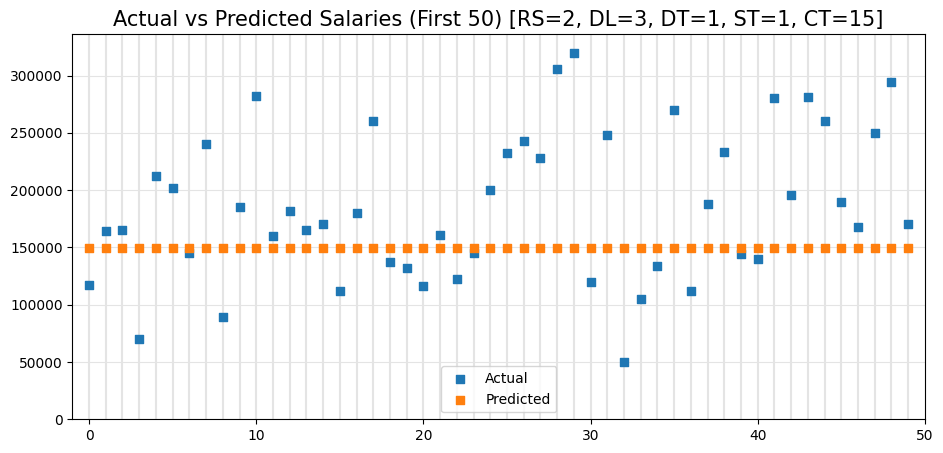

In [186]:
# Compare the predicted salaries against the actual ones in a visualization, for the first 50 salaries of the test set
if x_test.shape[0] < 50:  rows = x_test.shape[0]
else:  rows = 50
plt.figure(figsize=(11,5))
plt.axis([-1,rows,0,y_test.iloc[:rows].max()*1.05])
for i in range(rows):
    # print("{:20} | {:8}".format(y_pred[i], y_test.iloc[i]))
    plt.axvline(i, color='#e4e4e4', zorder=2)
plt.scatter(range(rows), y_test.iloc[:rows], marker='s',label='Actual', zorder=4)
plt.scatter(range(rows), y_pred[:rows], marker='s',label='Predicted', zorder=4)
plt.title("Actual vs Predicted Salaries (First {}) [RS={}, DL={}, DT={}, ST={}, CT={}]".format(
    rows, random_state, dl_model, dropna_type, subset_type, column_type), fontsize=15)
# for i in range(rows):
#     plt.axvline(i, ymin=y_test.iloc[i]/(y_test.iloc[:rows].max()*1.05), ymax=y_pred[i]/(y_test.iloc[:rows].max()*1.05), 
#                 color='black', zorder=3)
plt.legend()
plt.grid(color='#e4e4e4', axis='y', zorder=1)
plt.show()

In [187]:
def adjusted_r2_score(r2_score, n, k):
    return 1 - (1-r2_score)*(n-1)/(n-k-1)

In [188]:
# Results of metrics
if random_state_in_use:
    print("### RESULTS OF METRICS | DL MODEL {} ###".format(dl_model))
    print("### RANDOM STATE {} | DROP NA TYPE {} | SUBSET TYPE {} | COLUMN TYPE {} || SIZE {}/{}/{} ###".format(
        random_state, dropna_type, subset_type, column_type, salaries.shape[0], x_train.shape[0], x_test.shape[0]))
else:   print("### SCORES FOR CUSTOM TRAIN-TEST SETS ###")
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 SCORE:", r2_score(y_test, y_pred))
print("ADJUSTED R2 SCORE:", adjusted_r2_score(r2_score(y_test, y_pred), len(y_test), X.shape[1]))

### RESULTS OF METRICS | DL MODEL 3 ###
### RANDOM STATE 2 | DROP NA TYPE 1 | SUBSET TYPE 1 | COLUMN TYPE 15 || SIZE 19554/17598/1956 ###
MSE:  6415912760.066702
RMSE: 80099.39300685556
MAE:  62106.25194913088
R2 SCORE: -0.02658135815955487
ADJUSTED R2 SCORE: -0.035586457792533555
